<a href="https://colab.research.google.com/github/AdityaaSaputraa/test/blob/main/Pemodelan_Sentimen_Analisis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install sastrawi
!pip install tensorflow
!pip install scikit-learn
!pip install pandas nltk wordcloud requests matplotlib seaborn
!pip install lightgbm xgboost catboost
!pip install dask[dataframe]

In [8]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import requests
import json
import string
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score
import time
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import pickle

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
df = pd.read_csv('hasil_scraping_axisnet.csv')

# Menampilkan 5 data teratas
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,519e0758-5223-4836-9686-41168b20805c,Ahmad sani malay Sani malay,https://play-lh.googleusercontent.com/a-/ALV-U...,jadikan perangkat mu dengan cepat dan lebih me...,5,0,10.1.0,2026-07-01 07:51:25,"Hi Kak, terima kasih telah menjadi pelanggan s...",2026-07-01 09:00:49,10.1.0
1,da949155-d275-4d44-8aa8-837b73c5db73,Agus Gustian17,https://play-lh.googleusercontent.com/a/ACg8oc...,xsis tolol jaringan ngeleg terus maen epep aja...,1,0,10.1.0,2026-07-01 07:42:28,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-07-01 09:00:51,10.1.0
2,09e3126b-c5fb-43a0-971f-233f056b87d6,Yad Yai,https://play-lh.googleusercontent.com/a/ACg8oc...,Indonesian,5,0,10.1.0,2026-07-01 07:31:44,"Hi Kak, terima kasih sudah memberikan penilaia...",2026-07-01 09:00:53,10.1.0
3,ad57d7cf-256c-4149-a40a-eee36a0b3c61,Al Bukhari,https://play-lh.googleusercontent.com/a/ACg8oc...,AXIS sebenarnya layanan yg bagus dan memadai t...,1,0,10.0.0,2026-07-01 07:28:34,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-01 09:00:56,10.0.0
4,813fc236-e69c-49bb-98f4-fc4e9a5dddbb,Yazli Lubis,https://play-lh.googleusercontent.com/a/ACg8oc...,banyak promo nyaa,5,0,10.0.0,2026-07-01 07:13:33,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-07-01 09:00:58,10.0.0


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
clean_df = df.dropna()

In [12]:
clean_df = clean_df.drop_duplicates()

In [13]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1277 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              1277 non-null   object
 1   userName              1277 non-null   object
 2   userImage             1277 non-null   object
 3   content               1277 non-null   object
 4   score                 1277 non-null   int64 
 5   thumbsUpCount         1277 non-null   int64 
 6   reviewCreatedVersion  1277 non-null   object
 7   at                    1277 non-null   object
 8   replyContent          1277 non-null   object
 9   repliedAt             1277 non-null   object
 10  appVersion            1277 non-null   object
dtypes: int64(2), object(9)
memory usage: 119.7+ KB


In [14]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,519e0758-5223-4836-9686-41168b20805c,Ahmad sani malay Sani malay,https://play-lh.googleusercontent.com/a-/ALV-U...,jadikan perangkat mu dengan cepat dan lebih me...,5,0,10.1.0,2026-07-01 07:51:25,"Hi Kak, terima kasih telah menjadi pelanggan s...",2026-07-01 09:00:49,10.1.0
1,da949155-d275-4d44-8aa8-837b73c5db73,Agus Gustian17,https://play-lh.googleusercontent.com/a/ACg8oc...,xsis tolol jaringan ngeleg terus maen epep aja...,1,0,10.1.0,2026-07-01 07:42:28,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-07-01 09:00:51,10.1.0
2,09e3126b-c5fb-43a0-971f-233f056b87d6,Yad Yai,https://play-lh.googleusercontent.com/a/ACg8oc...,Indonesian,5,0,10.1.0,2026-07-01 07:31:44,"Hi Kak, terima kasih sudah memberikan penilaia...",2026-07-01 09:00:53,10.1.0
3,ad57d7cf-256c-4149-a40a-eee36a0b3c61,Al Bukhari,https://play-lh.googleusercontent.com/a/ACg8oc...,AXIS sebenarnya layanan yg bagus dan memadai t...,1,0,10.0.0,2026-07-01 07:28:34,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-01 09:00:56,10.0.0
4,813fc236-e69c-49bb-98f4-fc4e9a5dddbb,Yazli Lubis,https://play-lh.googleusercontent.com/a/ACg8oc...,banyak promo nyaa,5,0,10.0.0,2026-07-01 07:13:33,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-07-01 09:00:58,10.0.0


In [15]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r"http\S+", '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ' '.join([word for word in text.split() if word.lower() not in ["mobile", "bni", "wondr", "bni mobile"]])
    text = text.strip(' ')
    return text

def casefoldingText(text):
    text = text.lower()
    return text

def tokenizingText(text):
    text = word_tokenize(text)
    return text

def filteringText(text):
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku','di','ya','loh','kah','deh'])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    stemmed_text = ' '.join(stemmed_words)
    return stemmed_text

def toSentence(list_words):
    sentence = ' '.join(word for word in list_words)
    return sentence

def fix_slangwords(text):
    words = text.split()
    fixed_words = []
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [16]:
url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/slangwords.json'

response = requests.get(url)

if response.status_code == 200:
    try:
        slangwords = json.loads(response.text)
    except json.JSONDecodeError as e:
        print("Error decoding JSON:", e)
        print("Response content:", response.text)
else:
    print("Failed to fetch data from URL. Status code:", response.status_code)

In [17]:
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [18]:
clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,519e0758-5223-4836-9686-41168b20805c,Ahmad sani malay Sani malay,https://play-lh.googleusercontent.com/a-/ALV-U...,jadikan perangkat mu dengan cepat dan lebih me...,5,0,10.1.0,2026-07-01 07:51:25,"Hi Kak, terima kasih telah menjadi pelanggan s...",2026-07-01 09:00:49,10.1.0,jadikan perangkat mu dengan cepat dan lebih me...,jadikan perangkat mu dengan cepat dan lebih me...,jadikan perangkat mu dengan cepat dan lebih me...,"[jadikan, perangkat, mu, dengan, cepat, dan, l...","[jadikan, perangkat, mu, cepat, memuat, instan...",jadikan perangkat mu cepat memuat instangak pakai
1,da949155-d275-4d44-8aa8-837b73c5db73,Agus Gustian17,https://play-lh.googleusercontent.com/a/ACg8oc...,xsis tolol jaringan ngeleg terus maen epep aja...,1,0,10.1.0,2026-07-01 07:42:28,"Hi Kak, mohon maaf ya kalau ada yang bikin ga ...",2026-07-01 09:00:51,10.1.0,xsis tolol jaringan ngeleg terus maen epep aja...,xsis tolol jaringan ngeleg terus maen epep aja...,xsis tolol jaringan ngeleg terus main epep saj...,"[xsis, tolol, jaringan, ngeleg, terus, main, e...","[xsis, tolol, jaringan, ngeleg, main, epep, ng...",xsis tolol jaringan ngeleg main epep ngeleg
2,09e3126b-c5fb-43a0-971f-233f056b87d6,Yad Yai,https://play-lh.googleusercontent.com/a/ACg8oc...,Indonesian,5,0,10.1.0,2026-07-01 07:31:44,"Hi Kak, terima kasih sudah memberikan penilaia...",2026-07-01 09:00:53,10.1.0,Indonesian,indonesian,indonesian,[indonesian],[indonesian],indonesian
3,ad57d7cf-256c-4149-a40a-eee36a0b3c61,Al Bukhari,https://play-lh.googleusercontent.com/a/ACg8oc...,AXIS sebenarnya layanan yg bagus dan memadai t...,1,0,10.0.0,2026-07-01 07:28:34,"Hi Kak, maaf ya, agar dapat dibantu cek lebih ...",2026-07-01 09:00:56,10.0.0,AXIS sebenarnya layanan yg bagus dan memadai t...,axis sebenarnya layanan yg bagus dan memadai t...,axis sebenarnya layanan yang bagus dan memadai...,"[axis, sebenarnya, layanan, yang, bagus, dan, ...","[axis, layanan, bagus, memadai, sayangnya, ben...",axis layanan bagus memadai sayangnya benci ket...
4,813fc236-e69c-49bb-98f4-fc4e9a5dddbb,Yazli Lubis,https://play-lh.googleusercontent.com/a/ACg8oc...,banyak promo nyaa,5,0,10.0.0,2026-07-01 07:13:33,"Hi Kak, terima kasih atas kepercayaannya untuk...",2026-07-01 09:00:58,10.0.0,banyak promo nyaa,banyak promo nyaa,banyak promo nyaa,"[banyak, promo, nyaa]","[promo, nyaa]",promo nyaa


In [19]:
def load_lexicon(url):
    lexicon = dict()
    response = requests.get(url)

    if response.status_code == 200:
        lines = response.text.strip().split('\n')
        for line in lines:
            parts = line.split(',')
            word = ','.join(parts[:-1])
            score = parts[-1]
            lexicon[word.strip()] = int(score.strip())
    else:
        print(f"Failed to fetch lexicon data from {url}")

    return lexicon

positive_lexicon_url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/LeksikonPositif.txt'
negative_lexicon_url = 'https://raw.githubusercontent.com/aninanandah/datasetproject/main/LeksikonNegatif.txt'

# Memuat leksikon positif dan negatif dari URL yang diberikan
lexicon_positive = load_lexicon(positive_lexicon_url)
lexicon_negative = load_lexicon(negative_lexicon_url)

In [20]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0

    for word in text:
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]

    for word in text:
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]

    polarity = ''

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'

    return score, polarity


In [21]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)


results = list(zip(*results))

clean_df['polarity_score'] = results[0]

clean_df['polarity'] = results[1]

print(clean_df['polarity'].value_counts())

polarity
negative    587
positive    415
neutral     275
Name: count, dtype: int64


In [22]:
X = clean_df['text_akhir']
y = clean_df['polarity']

In [23]:
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8, ngram_range=(1, 1))
X_tfidf = tfidf.fit_transform(X)

In [24]:
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
features_df

,aneh,aplikasi,axis,axisnet,bagus,banget,bantuan,beli,benerin,bikin,...,perbaiki,puas,pulsa,sinyal,sinyalnya,suka,susah,terima,unlimited,update
0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.223058,0.0,0.220826,0.000000,0.283317,0.000000,0.0,0.0,...,0.309789,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.400718,0.000000,0.0,0.0,...,0.438159,0.0,0.000000,0.511734,0.0,0.0,0.0,0.0,0.0,0.0
1273,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.593254,0.0,0.0,...,0.000000,0.0,0.256593,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1274,0.0,0.0,0.000000,0.0,0.632114,0.774875,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1275,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


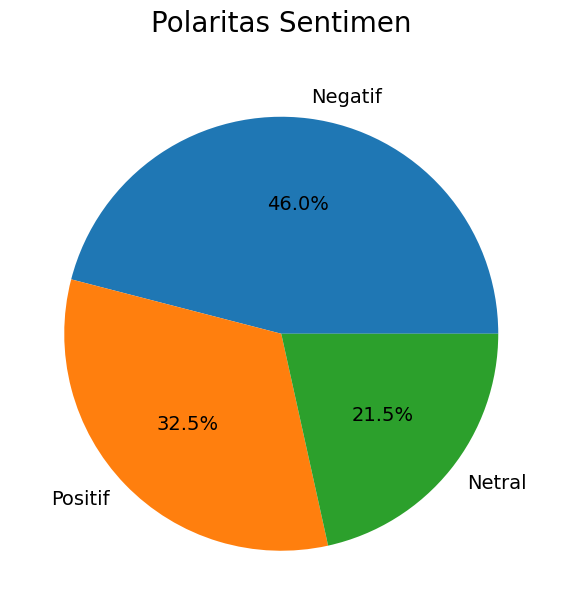

In [25]:
fig, ax = plt.subplots(figsize=(7, 8))
sizes = [count for count in clean_df['polarity'].value_counts()]
#labels = list(clean_df['polarity'].value_counts().index)  # Mengambil nama kategori polaritas sentimen
labels = ['Negatif', 'Positif', 'Netral']
explode = (0, 0, 0)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Polaritas Sentimen', fontsize=20, pad=22)
plt.show()

In [26]:
positive_review = clean_df[clean_df['polarity'] == 'positive']
positive_review = positive_review[['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
positive_review = positive_review.sort_values(by='polarity_score', ascending=False)
positive_review = positive_review.reset_index(drop=True)
positive_review.index += 1

In [27]:
negative_review = clean_df[clean_df['polarity'] == 'negative']
negative_review = negative_review[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
negative_review = negative_review.sort_values(by='polarity_score', ascending=False)
negative_review = negative_review.reset_index(drop=True)
negative_review.index += 1

In [28]:
neutral_review = clean_df[clean_df['polarity'] == 'neutral']
neutral_review = neutral_review[['text_akhir', 'polarity_score', 'polarity','text_stopword']]
neutral_review = neutral_review.sort_values(by='polarity_score', ascending=False)
neutral_review = neutral_review.reset_index(drop=True)
neutral_review.index += 1

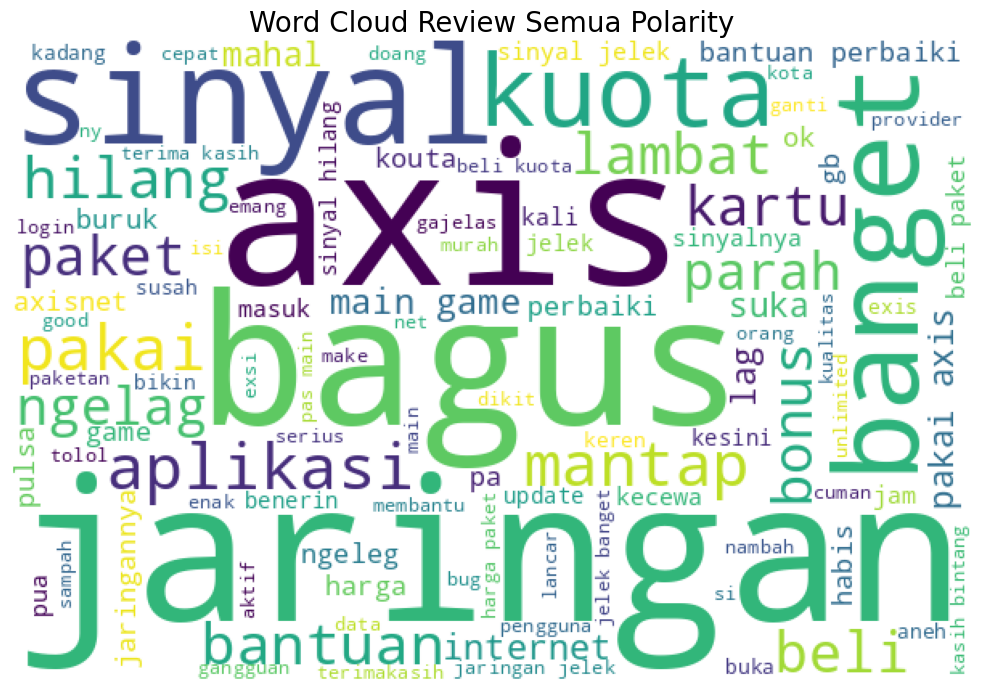

In [29]:
list_words = ''
for tweet in clean_df['text_stopword']:
    for word in tweet:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Review Semua Polarity', fontsize=20)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

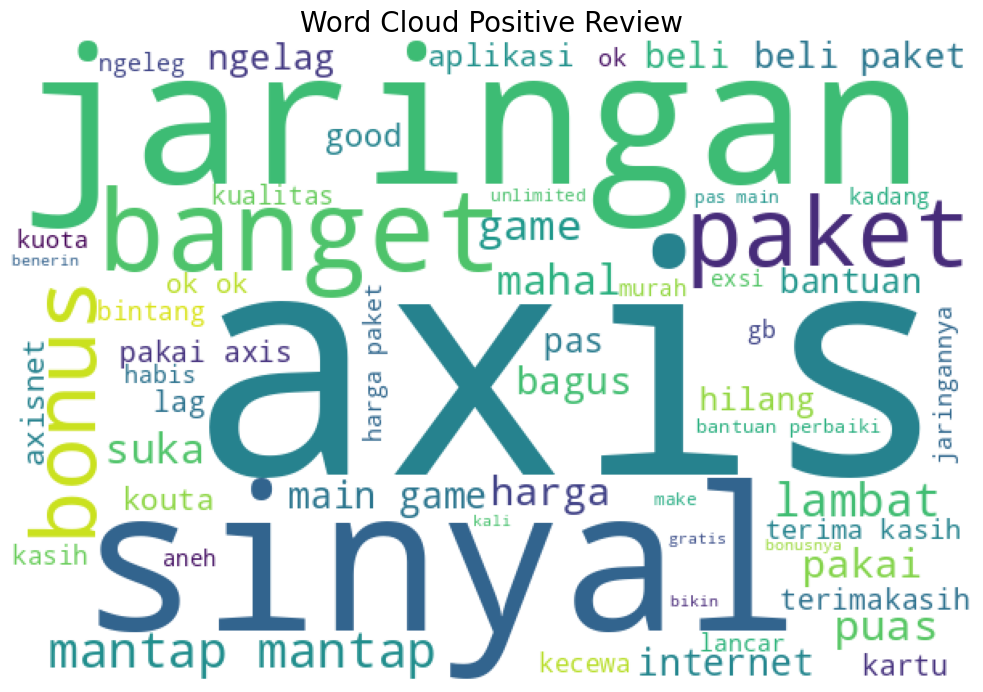

In [30]:
list_words = ''
for review in positive_review['text_stopword']:
    for word in review:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Positive Review', fontsize=20)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

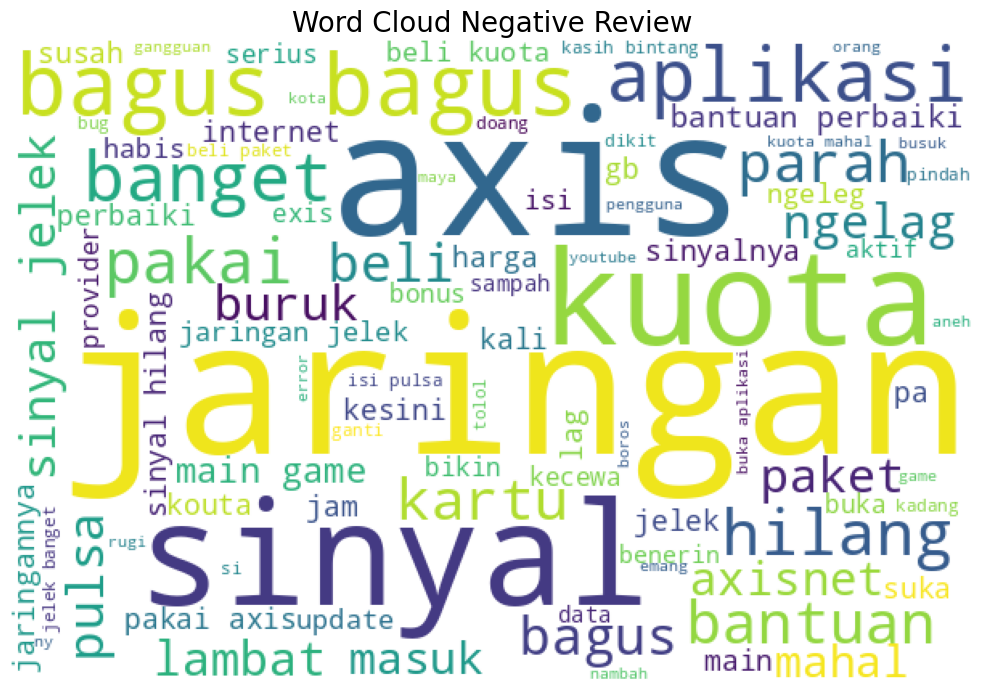

In [31]:
list_words = ''
for review in negative_review['text_stopword']:
    for word in review:
        list_words += ' ' + (word)

wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list_words)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title('Word Cloud Negative Review', fontsize=20)
ax.grid(False)
ax.imshow((wordcloud))
fig.tight_layout(pad=0)
ax.axis('off')
plt.show()

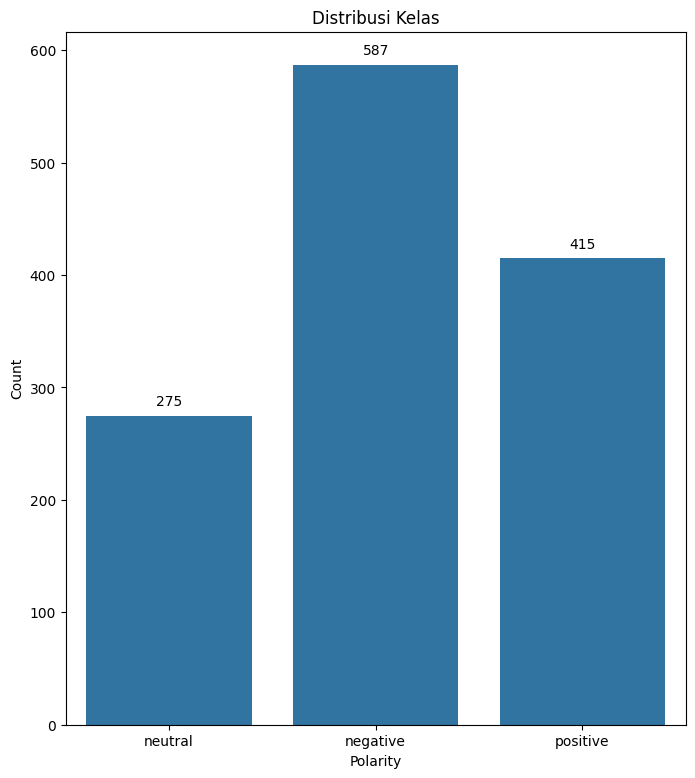

In [32]:
# Mengatur ukuran gambar plot
plt.figure(figsize=(8, 9))

# Membuat plot count menggunakan seaborn untuk variabel 'polarity' dari dataframe 'clean_df'
class_dist_plot = sns.countplot(x='polarity', data=clean_df)

# Menetapkan judul plot
plt.title('Distribusi Kelas')

# Menetapkan label sumbu x
plt.xlabel('Polarity')

# Menetapkan label sumbu y
plt.ylabel('Count')

# Menambahkan label angka untuk setiap bar pada plot
for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                             (p.get_x() + p.get_width() / 2., p.get_height()),
                             ha='center', va='center',
                             xytext=(0, 10),
                             textcoords='offset points')

# Menampilkan plot
plt.show()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=50)

In [34]:
from sklearn.linear_model import LogisticRegression

# Membuat objek model Logistic Regression
logistic_regression = LogisticRegression()

# Melatih model Logistic Regression pada data pelatihan
logistic_regression.fit(X_train.toarray(), y_train)

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluasi akurasi model Logistic Regression pada data pelatihan
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)

# Evaluasi akurasi model Logistic Regression pada data uji
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

# Menampilkan akurasi
print('Logistic Regression - accuracy_train:', accuracy_train_lr)
print('Logistic Regression - accuracy_test:', accuracy_test_lr)

Logistic Regression - accuracy_train: 0.8207639569049952
Logistic Regression - accuracy_test: 0.78515625


In [35]:
# Mengonversi sparse matrix ke array
X_train_array = X_train.toarray()
X_test_array = X_test.toarray()

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Membuat objek model XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42)

# Melatih model XGBoost pada data pelatihan
start_time = time.time()
xgb.fit(X_train_array, y_train_encoded)
execution_time = time.time() - start_time

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_xgb = xgb.predict(X_train_array)
y_pred_test_xgb = xgb.predict(X_test_array)

# Evaluasi akurasi model XGBoost pada data pelatihan
accuracy_train_xgb = accuracy_score(y_pred_train_xgb, y_train_encoded)

# Evaluasi akurasi model XGBoost pada data uji
accuracy_test_xgb = accuracy_score(y_pred_test_xgb, y_test_encoded)

# Menampilkan akurasi dan waktu eksekusi
print('XGBoost - accuracy_train:', accuracy_train_xgb)
print('XGBoost - accuracy_test:', accuracy_test_xgb)
print('XGBoost - execution_time:', execution_time, 'seconds')

XGBoost - accuracy_train: 0.9040156709108716
XGBoost - accuracy_test: 0.75390625
XGBoost - execution_time: 2.7153265476226807 seconds


In [36]:
from catboost import CatBoostClassifier
import time

# Membuat objek model CatBoost
cat_model = CatBoostClassifier(n_estimators=100, random_state=42, verbose=0)

# Melatih model CatBoost pada data pelatihan
start_time = time.time()
cat_model.fit(X_train.toarray(), y_train)
execution_time = time.time() - start_time

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_cat = cat_model.predict(X_train.toarray())
y_pred_test_cat = cat_model.predict(X_test.toarray())

# Evaluasi akurasi model CatBoost pada data pelatihan
accuracy_train_cat = accuracy_score(y_pred_train_cat, y_train)

# Evaluasi akurasi model CatBoost pada data uji
accuracy_test_cat = accuracy_score(y_pred_test_cat, y_test)

# Menampilkan akurasi dan waktu eksekusi
print('CatBoost - accuracy_train:', accuracy_train_cat)
print('CatBoost - accuracy_test:', accuracy_test_cat)
print('CatBoost - execution_time:', execution_time, 'seconds')

CatBoost - accuracy_train: 0.8873653281096964
CatBoost - accuracy_test: 0.78125
CatBoost - execution_time: 0.8851983547210693 seconds


In [37]:
# Membuat objek model SVM
svm = SVC(kernel='linear')

# Melatih model SVM pada data pelatihan
start_time = time.time()
svm.fit(X_train.toarray(), y_train)
execution_time = time.time() - start_time

# Prediksi sentimen pada data pelatihan dan data uji
y_pred_train_svm = svm.predict(X_train.toarray())
y_pred_test_svm = svm.predict(X_test.toarray())

# Evaluasi akurasi model SVM pada data pelatihan
accuracy_train_svm = accuracy_score(y_pred_train_svm, y_train)

# Evaluasi akurasi model SVM pada data uji
accuracy_test_svm = accuracy_score(y_pred_test_svm, y_test)

# Menampilkan akurasi dan waktu eksekusi
print('SVM - accuracy_train:', accuracy_train_svm)
print('SVM - accuracy_test:', accuracy_test_svm)
print('SVM - execution_time:', execution_time, 'seconds')

SVM - accuracy_train: 0.8227228207639569
SVM - accuracy_test: 0.78515625
SVM - execution_time: 0.0378880500793457 seconds


In [38]:
# Membuat DataFrame untuk hasil akurasi
results_df = pd.DataFrame({
    'Model': ['Logistic Regression','Support Vector Machine','Extreme Gradient Boosting','Categorical Boosting'],
    'Accuracy Train': [accuracy_train_lr, accuracy_train_svm, accuracy_train_xgb, accuracy_train_cat],
    'Accuracy Test': [accuracy_test_lr, accuracy_test_svm, accuracy_test_xgb, accuracy_test_cat]
})

# Menampilkan hanya kolom "Accuracy Test"
accuracy_test_only = results_df[['Model','Accuracy Train', 'Accuracy Test']]

# Mengurutkan DataFrame berdasarkan kolom "Accuracy Test" dari tertinggi ke terendah
accuracy_test_sorted = accuracy_test_only.sort_values(by='Accuracy Test', ascending=False)

# Menampilkan DataFrame yang telah diurutkan
print(accuracy_test_sorted)

                       Model  Accuracy Train  Accuracy Test
0        Logistic Regression        0.820764       0.785156
1     Support Vector Machine        0.822723       0.785156
3       Categorical Boosting        0.887365       0.781250
2  Extreme Gradient Boosting        0.904016       0.753906


In [39]:
# Simpan model SVM
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

In [40]:
# Simpan TfidfVectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [41]:
!pip freeze > requirements.txt